In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("../Data/attributes/structured_component_dataset_v1.csv")

print("Shape:", df.shape)
df.head()

Shape: (155, 26)


,image,component_id,class_id,component,confidence,x1,y1,x2,y2,width,...,normalized_y,normalized_width,normalized_height,brightness,contrast,min_intensity,max_intensity,detected_text,has_text,text_count
0,10002.png,0,2,CheckedTextView,0.502286,0.821686,82.077820,84.756989,284.991638,83.935303,...,0.071693,0.058288,0.079263,179.031471,44.581621,50,255,NaN,False,0
1,10010.png,0,2,CheckedTextView,0.630227,0.432907,83.921669,83.684662,280.505280,83.251755,...,0.071177,0.057814,0.076790,158.619350,33.390921,146,255,NaN,False,0
2,10010.png,1,2,CheckedTextView,0.427453,23.193726,80.703644,1363.871338,285.599701,1340.677612,...,0.071544,0.931026,0.080038,186.758748,39.678008,146,255,NaN,False,0
3,10010.png,2,3,EditText,0.278310,0.000000,80.900490,82.139648,278.541290,82.139648,...,0.070203,0.057041,0.077203,159.714400,35.140015,146,255,NaN,False,0
4,10031.png,0,2,CheckedTextView,0.597760,1.192478,86.552521,83.562469,278.167755,82.369991,...,0.071234,0.057201,0.074850,89.039634,28.920227,84,255,NaN,False,0


In [3]:
print(df.info())

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nComponent distribution:")
print(df["component"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   image              155 non-null    str    
 1   component_id       155 non-null    int64  
 2   class_id           155 non-null    int64  
 3   component          155 non-null    str    
 4   confidence         155 non-null    float64
 5   x1                 155 non-null    float64
 6   y1                 155 non-null    float64
 7   x2                 155 non-null    float64
 8   y2                 155 non-null    float64
 9   width              155 non-null    float64
 10  height             155 non-null    float64
 11  area               155 non-null    float64
 12  aspect_ratio       155 non-null    float64
 13  center_x           155 non-null    float64
 14  center_y           155 non-null    float64
 15  normalized_x       155 non-null    float64
 16  normalized_y       155 non-null    fl

In [4]:
df["detected_text"] = df["detected_text"].fillna("")

df["has_text"] = df["has_text"].astype(bool)

print("Missing detected_text:", df["detected_text"].isna().sum())

Missing detected_text: 0


In [5]:
features = [
    "width",
    "height",
    "area",
    "aspect_ratio",
    "center_x",
    "center_y",
    "normalized_x",
    "normalized_y",
    "normalized_width",
    "normalized_height",
    "brightness",
    "contrast",
    "min_intensity",
    "max_intensity",
    "confidence",
    "has_text",
]

X = df[features].copy()

X["has_text"] = X["has_text"].astype(int)

print("Feature shape:", X.shape)
X.head()

Feature shape: (155, 16)


,width,height,area,aspect_ratio,center_x,center_y,normalized_x,normalized_y,normalized_width,normalized_height,brightness,contrast,min_intensity,max_intensity,confidence,has_text
0,83.935303,202.913818,17031.632773,0.413650,42.789337,183.534729,0.029715,0.071693,0.058288,0.079263,179.031471,44.581621,50,255,0.502286,0
1,83.251755,196.583611,16365.930534,0.423493,42.058784,182.213474,0.029207,0.071177,0.057814,0.076790,158.619350,33.390921,146,255,0.630227,0
2,1340.677612,204.896057,274699.556642,6.543208,693.532532,183.151672,0.481620,0.071544,0.931026,0.080038,186.758748,39.678008,146,255,0.427453,0
3,82.139648,197.640800,16234.145868,0.415601,41.069824,179.720890,0.028521,0.070203,0.057041,0.077203,159.714400,35.140015,146,255,0.278310,0
4,82.369991,191.615234,15783.345189,0.429872,42.377474,182.360138,0.029429,0.071234,0.057201,0.074850,89.039634,28.920227,84,255,0.597760,0


In [6]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
width,155.0,226.695064,283.227331,56.019806,81.912468,82.933334,269.592651,1340.677612
height,155.0,198.568720,5.737233,179.007553,195.997086,197.473816,199.117573,234.590958
area,155.0,45241.223691,57049.896908,10932.663543,16116.736625,16395.241701,53954.340640,274699.556642
aspect_ratio,155.0,1.136970,1.409736,0.287050,0.414589,0.422264,1.364073,6.543208
center_x,155.0,140.006085,177.181367,40.450165,41.442580,42.923798,168.440399,826.670166
center_y,155.0,176.324940,19.754157,89.511757,180.879660,181.880245,182.801546,188.552094
normalized_x,155.0,0.097226,0.123043,0.028090,0.028780,0.029808,0.116972,0.574077
normalized_y,155.0,0.068877,0.007716,0.034966,0.070656,0.071047,0.071407,0.073653
normalized_width,155.0,0.157427,0.196686,0.038903,0.056884,0.057593,0.187217,0.931026
normalized_height,155.0,0.077566,0.002241,0.069925,0.076561,0.077138,0.077780,0.091637


In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (155, 16)


In [8]:
inertias = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

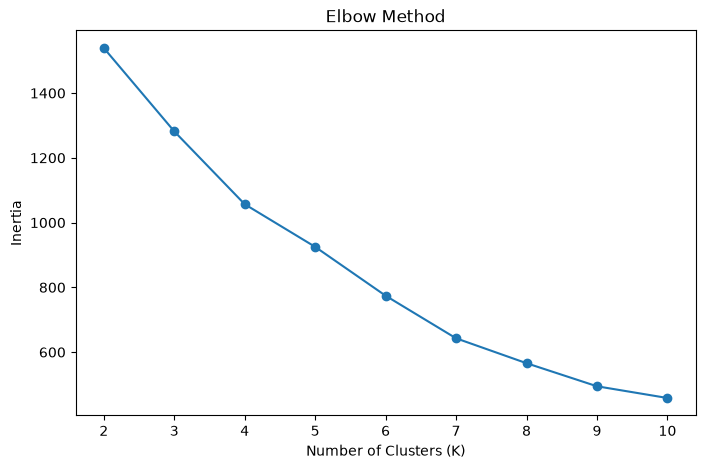

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, inertias, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [10]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"K={k}: Silhouette Score = {score:.4f}")

K=2: Silhouette Score = 0.4950
K=3: Silhouette Score = 0.5246
K=4: Silhouette Score = 0.3179
K=5: Silhouette Score = 0.3375
K=6: Silhouette Score = 0.3230
K=7: Silhouette Score = 0.3400
K=8: Silhouette Score = 0.3533
K=9: Silhouette Score = 0.3379
K=10: Silhouette Score = 0.3385


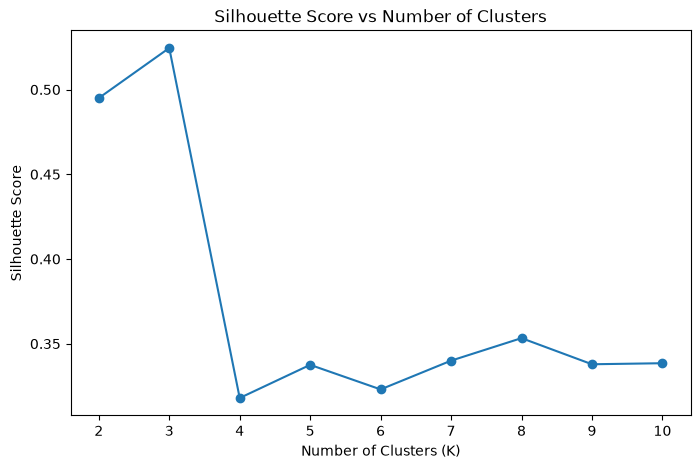

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, silhouette_scores, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")

plt.show()

In [12]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

df["cluster"] = kmeans.fit_predict(X_scaled)

print("Clusters created:", df["cluster"].nunique())

Clusters created: 3


In [13]:
cluster_counts = df["cluster"].value_counts().sort_index()

print(cluster_counts)

cluster
0    128
1     18
2      9
Name: count, dtype: int64


In [14]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.4289934  0.16865046]
Total explained variance: 0.5976438572670899


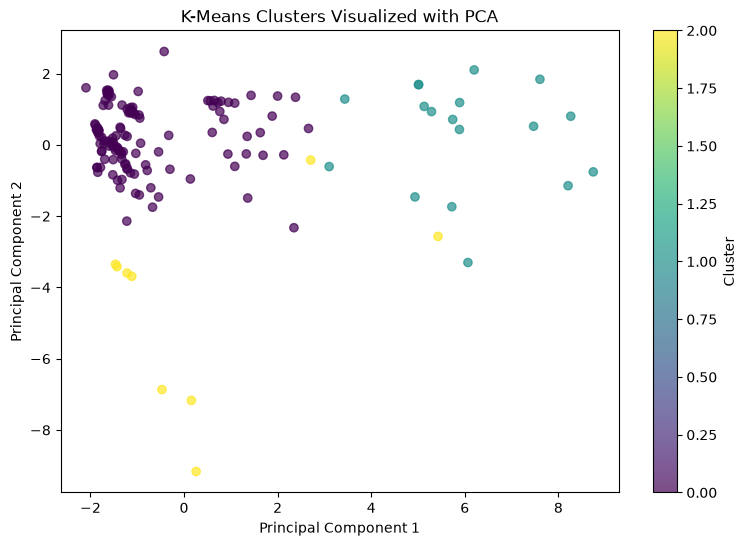

In [15]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"], alpha=0.7)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Visualized with PCA")

plt.colorbar(scatter, label="Cluster")

plt.show()

In [16]:
cluster_component_counts = pd.crosstab(df["cluster"], df["component"])

cluster_component_counts

component,Button,CheckBox,CheckedTextView,EditText
cluster,,,,
0,37,2,54,35
1,0,2,16,0
2,4,1,1,3


In [17]:
cluster_component_percentage = (
    pd.crosstab(df["cluster"], df["component"], normalize="index") * 100
)

cluster_component_percentage.round(2)

component,Button,CheckBox,CheckedTextView,EditText
cluster,,,,
0,28.91,1.56,42.19,27.34
1,0.00,11.11,88.89,0.00
2,44.44,11.11,11.11,33.33


In [18]:
cluster_summary = df.groupby("cluster")[features].mean()

cluster_summary.round(3)

,width,height,area,aspect_ratio,center_x,center_y,normalized_x,normalized_y,normalized_width,normalized_height,brightness,contrast,min_intensity,max_intensity,confidence,has_text
cluster,,,,,,,,,,,,,,,,
0,131.156,197.791,26009.794,0.662,82.378,181.331,0.057,0.071,0.091,0.077,118.774,45.819,85.195,255.0,0.639,0.008
1,912.503,201.096,183692.323,4.537,561.807,177.353,0.390,0.069,0.634,0.079,141.602,53.496,64.722,255.0,0.414,0.000
2,213.857,204.579,41852.689,1.098,116.005,103.077,0.081,0.040,0.149,0.080,139.760,42.046,98.889,255.0,0.591,0.000


In [19]:
cluster_component_summary = (
    df.groupby(["cluster", "component"])
    .size()
    .reset_index(name="count")
    .sort_values(["cluster", "count"], ascending=[True, False])
)

cluster_component_summary

,cluster,component,count
2,0,CheckedTextView,54
0,0,Button,37
3,0,EditText,35
1,0,CheckBox,2
5,1,CheckedTextView,16
4,1,CheckBox,2
6,2,Button,4
9,2,EditText,3
7,2,CheckBox,1
8,2,CheckedTextView,1


In [20]:
cluster_profile = []

for cluster_id in sorted(df["cluster"].unique()):
    cluster_data = df[df["cluster"] == cluster_id]

    top_component = cluster_data["component"].value_counts().idxmax()
    top_component_percentage = (
        cluster_data["component"].value_counts(normalize=True).iloc[0] * 100
    )

    cluster_profile.append(
        {
            "cluster": cluster_id,
            "size": len(cluster_data),
            "top_component": top_component,
            "top_component_percentage": round(top_component_percentage, 2),
            "avg_width": round(cluster_data["width"].mean(), 2),
            "avg_height": round(cluster_data["height"].mean(), 2),
            "avg_area": round(cluster_data["area"].mean(), 2),
            "avg_aspect_ratio": round(cluster_data["aspect_ratio"].mean(), 2),
            "avg_confidence": round(cluster_data["confidence"].mean(), 3),
        }
    )

cluster_profile_df = pd.DataFrame(cluster_profile)

cluster_profile_df

,cluster,size,top_component,top_component_percentage,avg_width,avg_height,avg_area,avg_aspect_ratio,avg_confidence
0,0,128,CheckedTextView,42.19,131.16,197.79,26009.79,0.66,0.639
1,1,18,CheckedTextView,88.89,912.50,201.10,183692.32,4.54,0.414
2,2,9,Button,44.44,213.86,204.58,41852.69,1.10,0.591


In [21]:
output_path = "../Data/attributes/structured_component_dataset_v1_clustered.csv"

df.to_csv(output_path, index=False)

print("Saved:", output_path)
print("Shape:", df.shape)

Saved: ../Data/attributes/structured_component_dataset_v1_clustered.csv
Shape: (155, 27)
